In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL']='3'
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
X = np.arange(-500, 500, 4)
y = np.arange(-490, 510, 4)
X_train = X[:200]
y_train = y[:200]
X_test = X[200:]
y_test = y[200:]


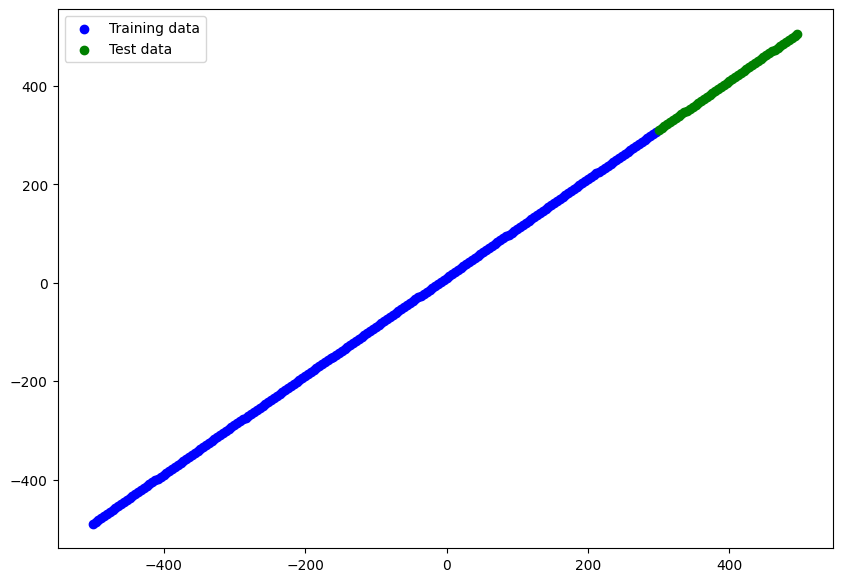

In [3]:
plt.figure(figsize=(10, 7))
plt.scatter(X_train, y_train, c="b", label="Training data")
plt.scatter(X_test, y_test, c="g", label="Test data")
plt.legend()
plt.show()

In [4]:
tf.random.set_seed(42)

model = tf.keras.models.Sequential([
    tf.keras.layers.Dense(4),
    tf.keras.layers.Dense(1)
])

model.compile(loss=tf.keras.losses.mae,
              optimizer=tf.keras.optimizers.Adam(),
              metrics=['mae'])

model.fit(tf.expand_dims(X_train, axis=-1), y_train, epochs=500, verbose=0)

In [5]:
model.evaluate(X_test, y_test)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.2327 - mae: 0.2327


[0.23274414241313934, 0.23274414241313934]

In [6]:
y_preds = model.predict(X_test)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


In [7]:
mae = tf.keras.metrics.mae(y_test, y_preds.squeeze()).numpy()
mse = tf.keras.metrics.mse(y_test, y_preds.squeeze()).numpy()
mae, mse

(np.float32(0.23274414), np.float32(0.055346683))

In [8]:
def plot_predictions(train_data=X_train, train_label=y_train, test_data=X_test, test_label=y_test, predictions=y_preds):
    plt.figure(figsize=(10, 7))
    plt.scatter(train_data, train_label, c="b", label="Training data")
    plt.scatter(test_data, test_label, c="g", label="Test data")
    plt.scatter(test_data, predictions, c="r", label="Predictions")
    plt.legend()
    plt.show()

In [9]:
def mae(y_true, y_pred):
    return tf.metrics.mae(y_true, y_pred.squeeze()).numpy()


def mse(y_true, y_pred):
    return tf.metrics.mse(y_true, y_pred.squeeze()).numpy()

In [10]:
# entrenamos un primer modelo
tf.random.set_seed(42)

model_1 = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(1,)),
    tf.keras.layers.Dense(4),
    tf.keras.layers.Dense(1)
])

model_1.compile(loss=tf.keras.losses.mae,
                optimizer=tf.keras.optimizers.Adam(),
                metrics=['mae'])

history_1 = model_1.fit(tf.expand_dims(X_train, axis=-1), y_train, epochs=500, verbose=0)

In [11]:
model_1.evaluate(X_test, y_test)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.3749 - mae: 0.3749


[0.37492918968200684, 0.37492918968200684]

In [12]:
y_preds_1 = model_1.predict(X_test)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


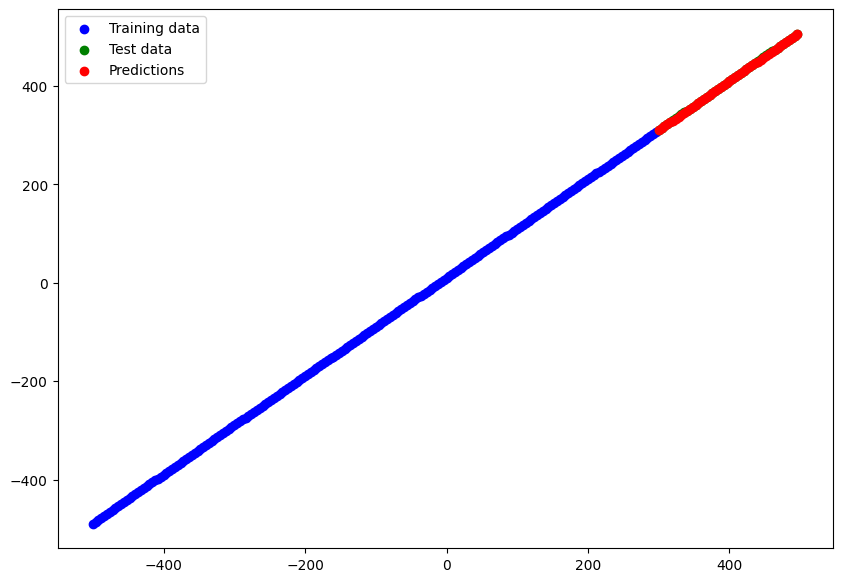

In [13]:
plot_predictions(train_data=X_train, train_label=y_train, test_data=X_test, test_label=y_test, predictions=y_preds_1)

In [14]:
mae_1 = mae(y_test, y_preds_1)
# %%
mse_1 = mse(y_test, y_preds_1)
mae_1, mse_1

(np.float32(0.3749292), np.float32(0.1436016))

In [15]:
# Segundo modelo
tf.random.set_seed(42)

model_2 = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(1,)),
    tf.keras.layers.Dense(4),
    tf.keras.layers.Dense(4),
    tf.keras.layers.Dense(1)
])

model_2.compile(loss=tf.keras.losses.mae,
                optimizer=tf.keras.optimizers.Adam(),
                metrics=['mae'])

history_2 = model_2.fit(tf.expand_dims(X_train, axis=-1), y_train, epochs=500, verbose=0)

In [16]:
model_2.evaluate(X_test, y_test)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 1.5997 - mae: 1.5997


[1.5996618270874023, 1.5996618270874023]

In [17]:
y_preds_2 = model_2.predict(X_test)

1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/stepWARNING:tensorflow:6 out of the last 6 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x797778121e40> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


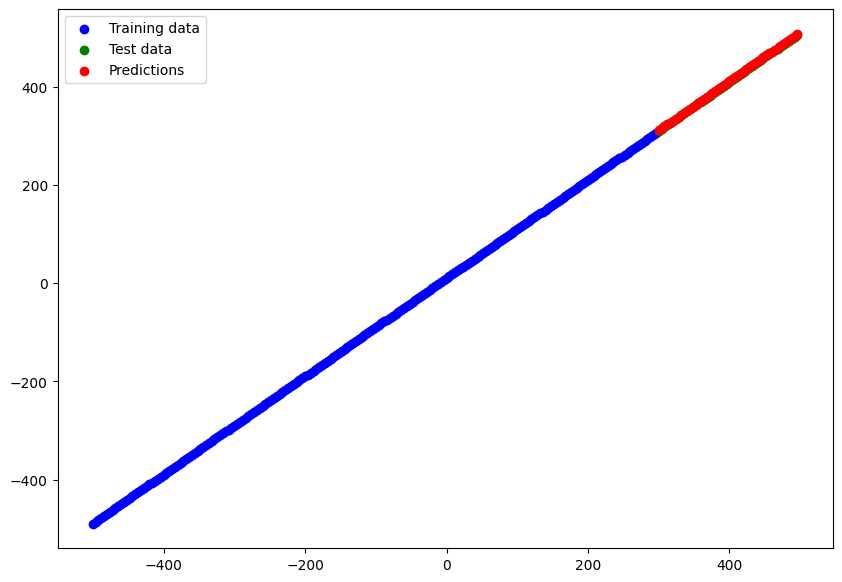

In [18]:
plot_predictions(predictions=y_preds_2)

In [19]:
mae_2 = mae(y_test, y_preds_2)
# %%
mse_2 = mse(y_test, y_preds_2)
mae_2, mse_2

(np.float32(1.5996618), np.float32(2.6126468))

In [20]:
# creamos un tercer modelo
tf.random.set_seed(42)

model_3 = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(1,)),
    tf.keras.layers.Dense(4),
    tf.keras.layers.Dense(16),
    tf.keras.layers.Dense(4),
    tf.keras.layers.Dense(1)
])

model_3.compile(loss=tf.keras.losses.mae,
                optimizer=tf.keras.optimizers.Adam(),
                metrics=['mae'])

history_3 = model_3.fit(tf.expand_dims(X_train, axis=-1), y_train, epochs=500, verbose=0)

In [21]:
model_3.evaluate(X_test, y_test)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0444 - mae: 0.0444 


[0.04442443698644638, 0.04442443698644638]

In [22]:
y_preds_3 = model_3.predict(X_test)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step


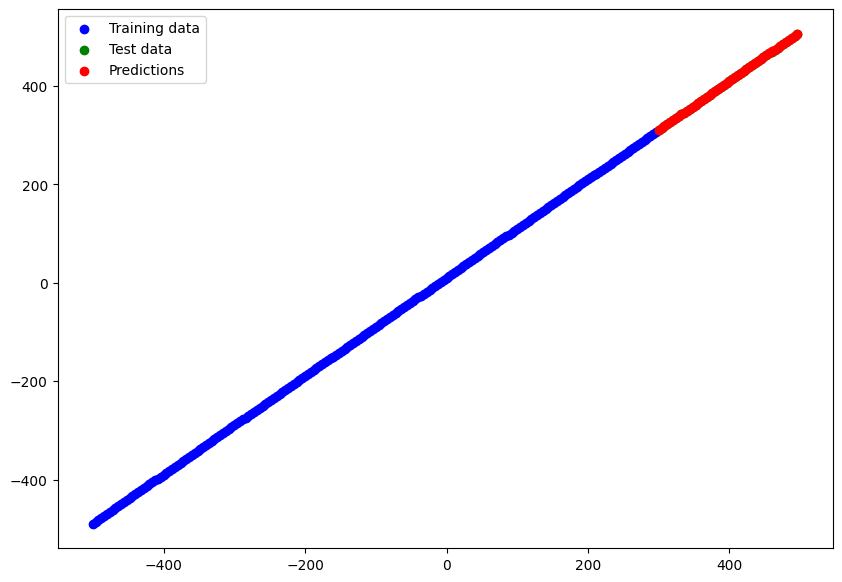

In [23]:
plot_predictions(predictions=y_preds_3)

In [24]:
mae_3 = mae(y_test, y_preds_3)
# %%
mse_3 = mse(y_test, y_preds_3)
mae_3, mse_3

(np.float32(0.044424437), np.float32(0.002059661))

In [25]:
model_results = [["model_1", mae_1, mse_1],
                 ["model_2", mae_2, mse_2],
                 ["model_3", mae_3, mse_3]]

In [26]:
all_results = pd.DataFrame(model_results, columns=["model", "mae", "mse"])
all_results

,model,mae,mse
0,model_1,0.374929,0.143602
1,model_2,1.599662,2.612647
2,model_3,0.044424,0.002060


In [27]:
insurance = pd.read_csv("https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv")
insurance.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [28]:
insurance_one_hot = pd.get_dummies(insurance)
insurance_one_hot.head()

,age,bmi,children,charges,sex_female,sex_male,smoker_no,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,True,False,False,True,False,False,False,True
1,18,33.770,1,1725.55230,False,True,True,False,False,False,True,False
2,28,33.000,3,4449.46200,False,True,True,False,False,False,True,False
3,33,22.705,0,21984.47061,False,True,True,False,False,True,False,False
4,32,28.880,0,3866.85520,False,True,True,False,False,True,False,False


In [29]:
X = insurance_one_hot.drop("charges", axis=1)
y = insurance_one_hot["charges"]

In [30]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [40]:
tf.random.set_seed(42)

insurance_model = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(11, )),
    tf.keras.layers.Dense(64),
    tf.keras.layers.Dense(16),
    tf.keras.layers.Dense(16),
    tf.keras.layers.Dense(1)
])

insurance_model.compile(loss=tf.keras.losses.mae,
                        optimizer=tf.keras.optimizers.Adam(),
                        metrics=['mae'])

history = insurance_model.fit(X_train, y_train, epochs=500, verbose=0)


In [42]:
insurance_model.evaluate(X_test, y_test)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3168.8872 - mae: 3168.8872 


[3168.88720703125, 3168.88720703125]

<Axes: >

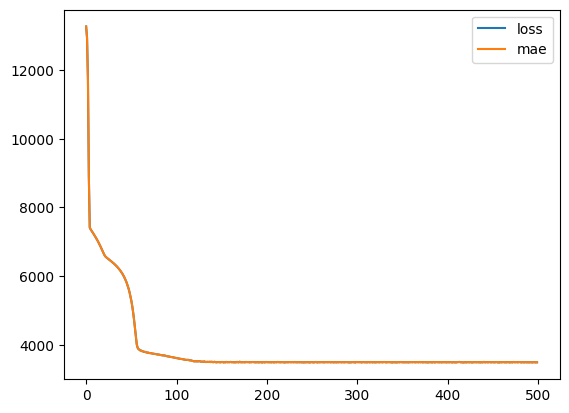

In [43]:
pd.DataFrame(history.history).plot()

In [45]:
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder

ct = make_column_transformer(
    (MinMaxScaler(), ["age", "bmi", "children"]),
    (OneHotEncoder(handle_unknown="ignore"), ["sex", "smoker", "region"])
)

X = insurance.drop("charges", axis=1)
y = insurance["charges"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train_normal = ct.fit_transform(X_train)
X_test_normal = ct.fit_transform(X_test)

In [46]:
tf.random.set_seed(42)

insurance_model_1 = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(11,)),
    tf.keras.layers.Dense(64),
    tf.keras.layers.Dense(16),
    tf.keras.layers.Dense(16),
    tf.keras.layers.Dense(1)
])

insurance_model_1.compile(loss=tf.keras.losses.mae,
                          optimizer=tf.keras.optimizers.Adam(),
                          metrics=['mae'])

history_1 = insurance_model_1.fit(X_train_normal, y_train, epochs=500, verbose=0)

In [47]:
insurance_model_1.evaluate(X_test_normal, y_test)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3161.1089 - mae: 3161.1089 


[3161.10888671875, 3161.10888671875]

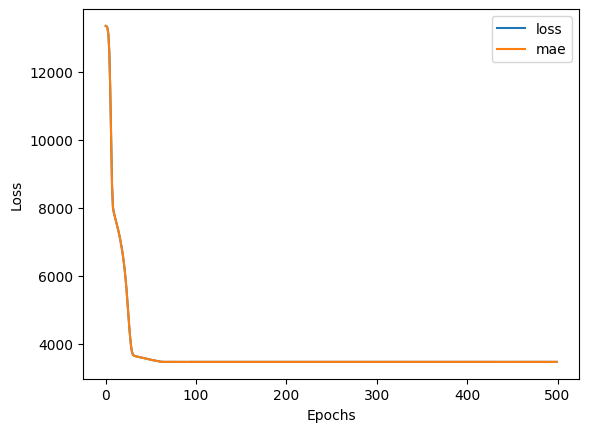

In [48]:
pd.DataFrame(history_1.history).plot()
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()